# N1 · ViT patchify: 图像如何变成 token (Vision Transformer)

> 配套 10.1-L1/L4 · 把一张合成图切成 patch、看它如何变成视觉 token, 跑一遍 mini-ViT,
> 对比 [CLS] vs 所有 patch token 的接口决策。

In [1]:
import sys
from pathlib import Path
SRC = Path.cwd().parent / "src"
sys.path.insert(0, str(SRC))
import numpy as np
import tiny_vit as tv
print('tiny_vit 就绪')

tiny_vit 就绪


## 1. 一张合成图 → patchify (L1 第①步)

图 (16, 16, 3) → 16 个 patch, 每个 48 维


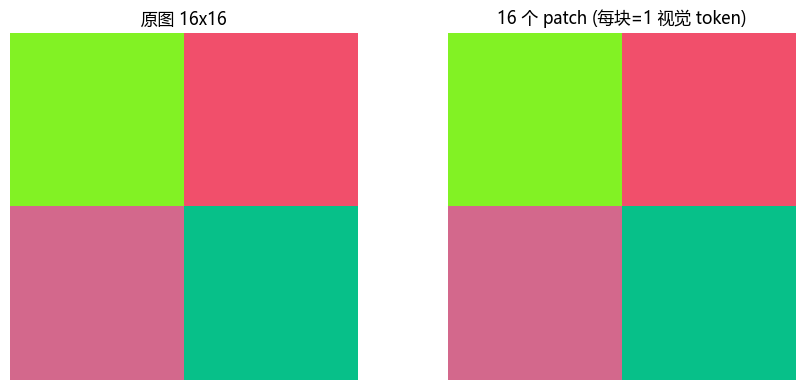

In [2]:
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams['axes.unicode_minus']=False
for f in ['Microsoft YaHei','SimHei','DejaVu Sans']:
    try: matplotlib.rcParams['font.sans-serif']=[f]; break
    except Exception: pass
img = tv.make_synthetic_image('blocks', size=16, seed=1)
patches = tv.patchify(img, patch=4)
print(f"图 {img.shape} → {patches.shape[0]} 个 patch, 每个 {patches.shape[1]} 维")
fig, axes = plt.subplots(1, 2, figsize=(9,4))
axes[0].imshow(img); axes[0].set_title('原图 16x16'); axes[0].axis('off')
# 把 16 个 patch 摆成 4x4 网格可视化
grid = patches.reshape(4,4,4,4,3)
canvas = np.zeros((16,16,3))
for i in range(4):
    for j in range(4):
        canvas[i*4:(i+1)*4, j*4:(j+1)*4] = grid[i,j]
axes[1].imshow(canvas); axes[1].set_title('16 个 patch (每块=1 视觉 token)'); axes[1].axis('off')
plt.tight_layout(); plt.show()

## 2. patch → 视觉 token (mini-ViT 前向, L1 第②-④步)

In [3]:
import torch
torch.manual_seed(0)
model = tv.build_tiny_vit(patch_dim=patches.shape[1], n_patches=patches.shape[0])
toks = model(torch.tensor(patches[None], dtype=torch.float32))
print(f"ViT 输出: {tuple(toks.shape)}  = (batch, 1 CLS + 16 patch, d_model=32)")
print("视觉 token 准备好了 —— 这就是后面接进 LLM 的'视觉一半'。")

ViT 输出: (1, 17, 32)  = (batch, 1 CLS + 16 patch, d_model=32)
视觉 token 准备好了 —— 这就是后面接进 LLM 的'视觉一半'。


## 3. 接口决策 (L4): [CLS] vs 所有 patch token

- 只用 [CLS]: 1 个 token, 全图摘要, 省上下文但丢空间细节。
- 所有 patch: 16 个 token, 保留位置, 但 LLM 上下文 ×16。

In [4]:
cls_tok = toks[:, 0]          # 图级摘要
patch_toks = toks[:, 1:]     # 位置级细节
print(f"只用 CLS:        给 LLM {cls_tok.shape[1]} 维 × 1 个 token")
print(f"用所有 patch:    给 LLM {patch_toks.shape[1]} 个 token (上下文 ×{patch_toks.shape[1]})")
print("\n→ 这就是 L4 决策一的核心权衡: 视觉细节 vs LLM 上下文成本。")
print("→ 高分辨率图 patch 上千 → 撑爆上下文 → 需要压缩 (M10.2 resampler)。")

只用 CLS:        给 LLM 32 维 × 1 个 token
用所有 patch:    给 LLM 16 个 token (上下文 ×16)

→ 这就是 L4 决策一的核心权衡: 视觉细节 vs LLM 上下文成本。
→ 高分辨率图 patch 上千 → 撑爆上下文 → 需要压缩 (M10.2 resampler)。


## 4. 反思
你亲手走通了「图 → patch → 视觉 token」这条 VLM 视觉地基的流水线, 并体会了 [CLS]/patch 的接口权衡。
下一步 N2: 这些视觉 token 凭什么「懂语言」? 看对比学习。